In [ ]:
import kagglehub

# Download latest version
df = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", df)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
df = pd.read_csv(os.path.join(df, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
pd.get_dummies(df)

,SeniorCitizen,tenure,MonthlyCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_No,Churn_Yes
0,0,1,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,34,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,2,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,2,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7039,0,72,103.20,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7040,0,11,29.60,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7041,1,4,74.40,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Handle TotalCharges: convert to numeric, coercing errors (empty strings) to NaN, then fill NaNs
# The previous output of pd.get_dummies implied TotalCharges was not numeric. We convert it here.
if not pd.api.types.is_numeric_dtype(df['TotalCharges']):
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0) # Fill NaN with 0 or a suitable imputation strategy

# Drop 'customerID' as it's an identifier and not a predictive feature
df_processed = df.drop('customerID', axis=1)

# Convert categorical features to dummy variables
# 'drop_first=True' helps avoid multicollinearity for binary categorical variables.
df_processed = pd.get_dummies(df_processed, drop_first=True)

# Define features (X) and target (y)
# Assuming 'Churn_Yes' is the target column after get_dummies and drop_first
X = df_processed.drop('Churn_Yes', axis=1)
y = df_processed['Churn_Yes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split successfully into training and testing sets.
X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6834 - loss: 3.4274 - val_accuracy: 0.7720 - val_loss: 1.5748
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7289 - loss: 0.9760 - val_accuracy: 0.5359 - val_loss: 0.8189
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7420 - loss: 0.7903 - val_accuracy: 0.6593 - val_loss: 0.5644
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7340 - loss: 0.8465 - val_accuracy: 0.7924 - val_loss: 0.6694
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7397 - loss: 0.8054 - val_accuracy: 0.7870 - val_loss: 0.8926
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7453 - loss: 1.0524 - val_accuracy: 0.7924 - val_loss: 0.5162
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7428 - loss: 1.0508 - val_accuracy: 0.7986 - val_loss: 0.4966
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7590 - loss: 0.6726 - val_accuracy: 0.

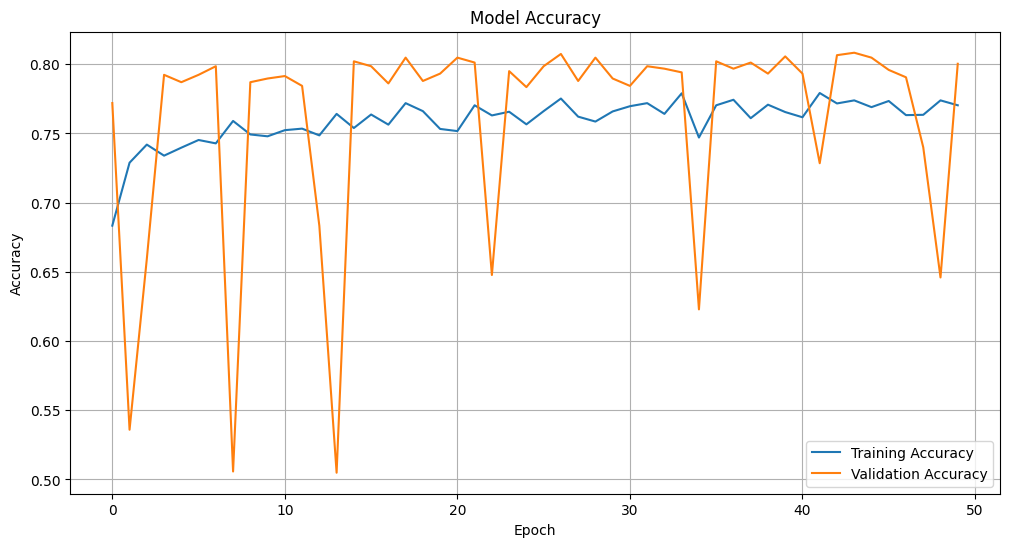

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

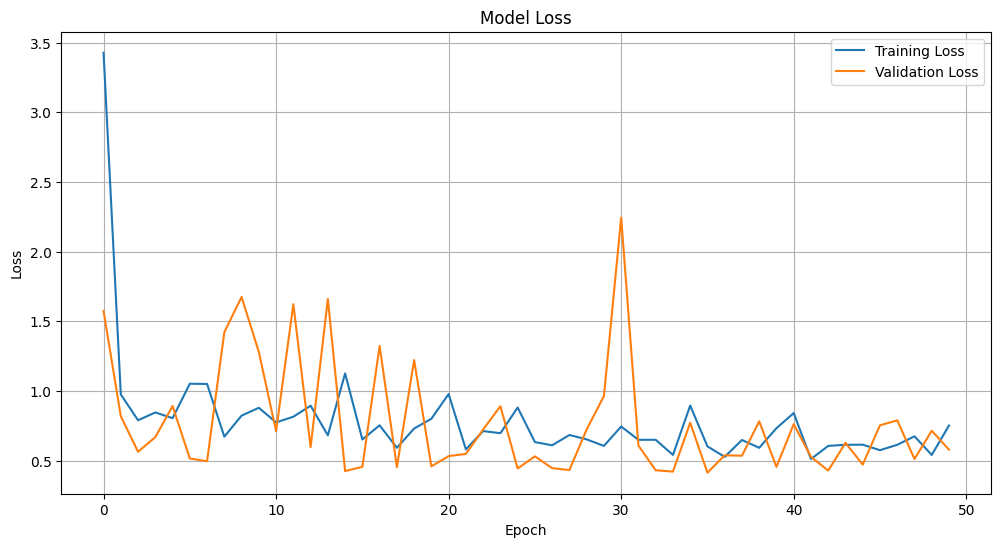

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict probabilities on the test set
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.8041
Precision: 0.6570
Recall: 0.5442
F1 Score: 0.5953
ROC-AUC: 0.8239


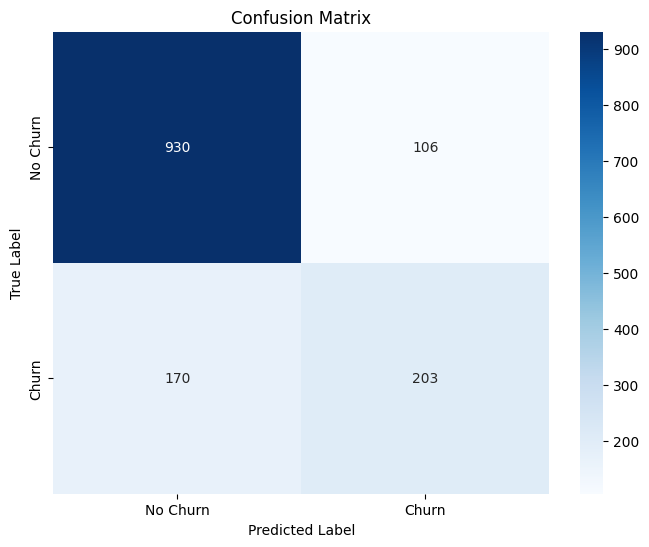

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Top 10 Key Indicators of Churn (ranked by absolute difference in churn rate/mean):
- TotalCharges: Indicator Strength = 1018.1153
- tenure: Indicator Strength = 19.5908
- MonthlyCharges: Indicator Strength = 13.1762
- Contract_Two year: Indicator Strength = 0.3122
- PaymentMethod_Electronic check: Indicator Strength = 0.2823
- InternetService_Fiber optic: Indicator Strength = 0.2740
- InternetService_No: Indicator Strength = 0.2442
- OnlineSecurity_No internet service: Indicator Strength = 0.2442
- OnlineBackup_No internet service: Indicator Strength = 0.2442
- DeviceProtection_No internet service: Indicator Strength = 0.2442


/tmp/ipykernel_8270/3586866231.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=features, palette='viridis')


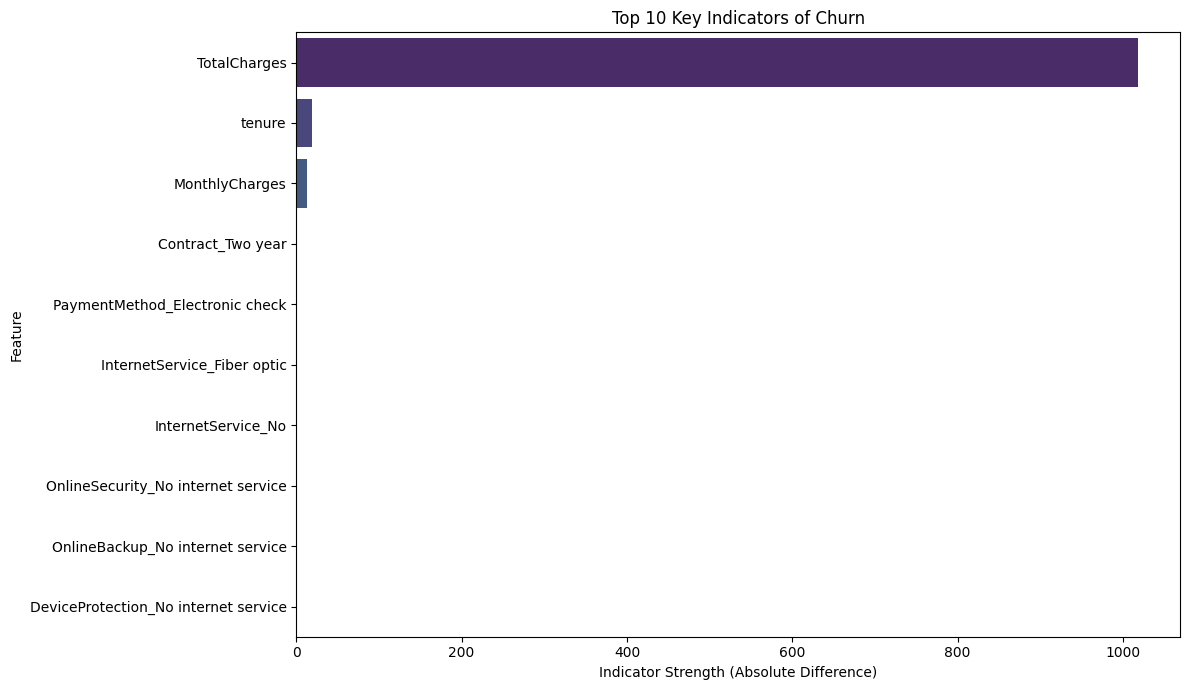

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy to avoid SettingWithCopyWarning
df_analysis = df_processed.copy()

# List to store feature importance scores
feature_importance_scores = {}

# Analyze numerical features (tenure, MonthlyCharges, TotalCharges)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numerical_cols:
    mean_churn_true = df_analysis[df_analysis['Churn_Yes'] == True][col].mean()
    mean_churn_false = df_analysis[df_analysis['Churn_Yes'] == False][col].mean()
    score = abs(mean_churn_true - mean_churn_false)
    feature_importance_scores[col] = score

# Analyze boolean/one-hot encoded features
# These are all other columns except numerical_cols and 'Churn_Yes'
boolean_cols = [col for col in df_analysis.columns if col not in numerical_cols + ['Churn_Yes']]
for col in boolean_cols:
    churn_rate_true = df_analysis[df_analysis[col] == True]['Churn_Yes'].mean()
    churn_rate_false = df_analysis[df_analysis[col] == False]['Churn_Yes'].mean()
    score = abs(churn_rate_true - churn_rate_false)
    feature_importance_scores[col] = score

# Sort features by importance score in descending order
sorted_indicators = sorted(feature_importance_scores.items(), key=lambda item: item[1], reverse=True)

# Get the top 10
top_10_indicators = sorted_indicators[:10]

print("Top 10 Key Indicators of Churn (ranked by absolute difference in churn rate/mean):")
for feature, score in top_10_indicators:
    print(f"- {feature}: Indicator Strength = {score:.4f}")

# Prepare data for visualization
features = [item[0] for item in top_10_indicators]
scores = [item[1] for item in top_10_indicators]

plt.figure(figsize=(12, 7))
sns.barplot(x=scores, y=features, palette='viridis')
plt.title('Top 10 Key Indicators of Churn')
plt.xlabel('Indicator Strength (Absolute Difference)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8270/1074201263.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


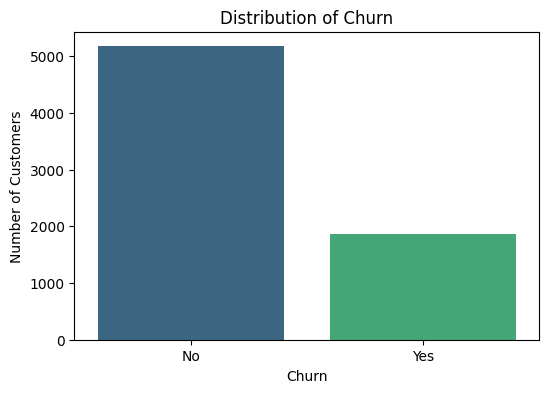

Churn distribution (counts):
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn distribution (percentages):
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the 'Churn' column
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Print the value counts for a numerical overview
print("Churn distribution (counts):\n", df['Churn'].value_counts())
print("\nChurn distribution (percentages):\n", df['Churn'].value_counts(normalize=True) * 100)